In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
sc.set_figure_params(dpi=100, dpi_save=1000, vector_friendly=True)
import matplotlib
from matplotlib import font_manager
import matplotlib.pyplot as plt
font_dirs = "/data/bonn-epyc/projects/robin/fonts"
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
matplotlib.pyplot.rcParams['font.family'] = "Arial"

In [2]:
## get data
tmp = sc.read("/data/bonn-epyc/projects/robin/segmentation/xenium_outs/adata_polygon_reduced_pseudotime_X26updated_with_quadrants_with_clusters.h5ad")
df_ps = pd.DataFrame(tmp.obsm["X_pca"][:,0], index=tmp.obs.index, columns=["PC1"])
adata = sc.read("/data/bonn-epyc/projects/zeba/MY_PROJECTS/240130_Xenium_ANCA_SLE_GBM/xenium-cgn/notebooks_zs/02_PeriglomDefinition_Sample26updated/output_dataobjects/adata_complete_reduced_withTransformedMC_X26updated.h5ad")
adata = adata[adata.obs.is_in_glom] ## only glom

adata.obs["celltype_l1"] = adata.obs["celltype_l1"].tolist()
adata.obs["celltype_l1"].replace({"Transformed mesangial": "Fibrotic MC",
                                        "mesangial cell": "MC",
                                        "podocyte": "POD"}, inplace=True)

sub = adata[adata.obs.polygon_flags.isin(df_ps.index.tolist())] ## subset on ones included in reduced data

/tmp/ipykernel_28629/3816351830.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["celltype_l1"] = adata.obs["celltype_l1"].tolist()
/tmp/ipykernel_28629/3816351830.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs["celltype_l1"].replace({"Transformed mesangial": "Fibrotic MC",


In [3]:
df_1 = sub.obs[["celltype_l1", "polygon_flags"]]
df_1.index = df_1.polygon_flags.tolist()

In [4]:
common = list(set(df_ps.index)&set(df_1.index))
df_ps, df_1 = df_ps.loc[common], df_1.loc[common]

In [5]:
df_ps = df_ps.loc[df_1.index]

In [6]:
df = pd.concat([df_ps, df_1], axis=1)

In [7]:
df.sort_values('PC1', inplace=True)

In [8]:
df = df.dropna(subset=["PC1"]) 

In [9]:
total_cells = df.groupby(['polygon_flags']).size().reset_index(name="TotalCells")

/tmp/ipykernel_28629/1056755574.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells = df.groupby(['polygon_flags']).size().reset_index(name="TotalCells")


In [10]:
## get composition
cell_counts = df.groupby(['polygon_flags', 'celltype_l1']).size().reset_index(name='CellCount')
cell_counts = cell_counts.merge(total_cells, on=['polygon_flags'])
cell_counts['Proportion'] = (cell_counts['CellCount'] / cell_counts['TotalCells']) * 100
cell_counts = cell_counts.merge(df, on=["polygon_flags"])
display(cell_counts.head())

/tmp/ipykernel_28629/725691619.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['polygon_flags', 'celltype_l1']).size().reset_index(name='CellCount')


,polygon_flags,celltype_l1_x,CellCount,TotalCells,Proportion,PC1,celltype_l1_y
0,0_0011216_ANCA_X17,ATL,0,189,0.0,0.512626,POD
1,0_0011216_ANCA_X17,ATL,0,189,0.0,0.512626,MC
2,0_0011216_ANCA_X17,ATL,0,189,0.0,0.512626,EC
3,0_0011216_ANCA_X17,ATL,0,189,0.0,0.512626,MC
4,0_0011216_ANCA_X17,ATL,0,189,0.0,0.512626,EC


In [11]:
cell_counts = cell_counts.iloc[:,:-1]
cell_counts.rename(columns={"celltype_l1_x": "celltype_l1"}, inplace=True)

In [12]:
pivot_table = cell_counts.pivot_table(index='PC1', columns='celltype_l1', values='Proportion', fill_value=0)
rolling_pivot_table = pivot_table.rolling(window=100, min_periods=1).mean()

In [13]:
new_colors_dict = {
    'POD': '#800080', 
    'PEC': '#008080',
    'MC': '#FFD700',

    'EC': '#00BFFF',
    'VSM/P': '#20B2AA',

    'PapE': '#006400',
    'PT': '#228B22',
    'ATL': '#32CD32',
    'CNT': '#90EE90',
    'DCT': '#98FB98',
    'DTL': '#00FA9A',
    'TAL': '#3CB371',

    'FIB': '#4682B4',
    'IC': '#1E90FF',
    'Fibrotic MC': "black",

    'NEU': '#FFD700',
    'PC': '#DAA520',

    'T': '#FF0000',
    'NKC/T': '#DC143C',

    'B': '#4169E1',
    'PL': '#6495ED',

    'N': '#800000',
    'MAC': '#A52A2A',
    'MDC': '#8B4513',
    'Mono': '#D2691E',

    'MAST': '#FF1493',
    'cDC': '#FF69B4',
    'pDC': '#DB7093',
    'cycMNP': '#FFB6C1',
    'cycNKC/T': '#FFC0CB'
}


In [14]:
celltypes = ["PEC", "MAC", "Fib. MC", "POD", "EC", "MC", "N", "NKC/T"]

In [15]:
specific_celltypes = {}
for key in celltypes:
    if key=="Fib. MC":
        specific_celltypes[key] = new_colors_dict["Fibrotic MC"]    
    else:
        specific_celltypes[key] = new_colors_dict[key]

In [16]:
rolling_pivot_table.rename(columns={"Fibrotic MC": "Fib. MC"}, inplace=True)

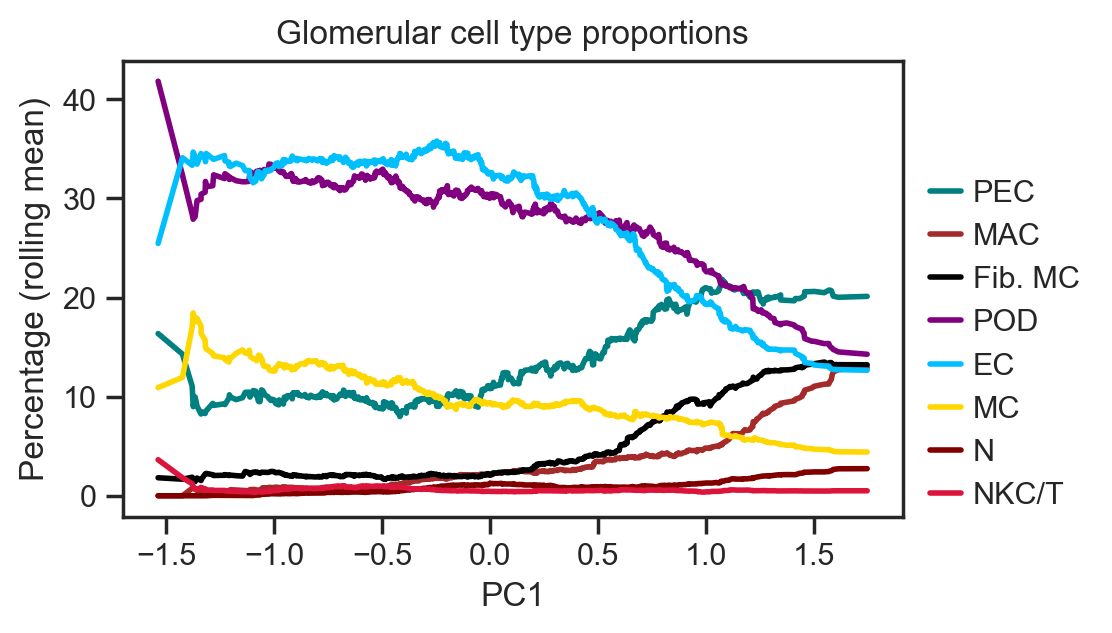

In [17]:
sns.set(style="ticks")

plt.figure(figsize=(5,3))

for cell_type in specific_celltypes:
    if cell_type in rolling_pivot_table.columns:
        line_data = rolling_pivot_table[cell_type]
        plt.plot(
            rolling_pivot_table.index, 
            line_data,
            label=cell_type,
            color=specific_celltypes[cell_type],
            linewidth=2,
        )

plt.title('Glomerular cell type proportions', fontweight='regular')
plt.xlabel('PC1', fontweight='regular')
plt.ylabel('Percentage (rolling mean)', fontweight='regular')

plt.legend(bbox_to_anchor=(1,0.8), frameon=False, handlelength=1)
plt.savefig("Fig3E-left.pdf", bbox_inches="tight")
plt.show()
